# Sampling with Negative Binomial Distribution

Recall the following details of the Negative Binomial Distribution pdf:

Given the following values:
- $n$ indicates the number of trials.
- $k$ indicates the number of successes needed for overall success.
- $p$ indicates the probability of success.
- $q=1-p$ indicates the probability of failure.
- $X$ represents the number of the last well drilled to achieve overall success.

The <span style = 'color: blue; font-weight:bold'>closed form pdf for a negative binomial distribution</span> is as follows:

$$P(X=x) = \binom{n-1}{k-1}p^kq^{n-k}$$

## The rflip() Function

We need to be able to use **rflip()** inside our **while loop.**

In [1]:
rflip <- function(n=1, prob=.5, quiet=FALSE, verbose = !quiet, summarize = FALSE, 
                  summarise = summarize) {
	if ( ( prob > 1 && is.integer(prob) ) ) {  
		# swap n and prob
		temp <- prob
		prob <- n
		n <- temp
	}
	if (summarise) {
	  heads <- rbinom(1, n, prob)
	  return(data.frame(n = n, heads = heads, tails = n - heads, prob = prob))
	} else {
	  r <- rbinom(n,1,prob)
	  result <- c('T','H')[ 1 + r ]
	  heads <- sum(r)
	  attr(heads,"n") <- n
	  attr(heads,"prob") <- prob 
	  attr(heads,"sequence") <- result
	  attr(heads,"verbose") <- verbose
	  class(heads) <- 'cointoss'
	  return(heads)
	}
}

The expected value is given below:

$$E(X) = \frac{k}{p}$$

Oil fields: 25\% chance of successes

$$E(X) = \frac{3}{\frac{1}{4}} = 12$$

## While Loop

Notice the && in the while loop stopping criteria. We have a two-part stopping criteria which says:

<center><span style = 'color:blue;font-weight:bold'>Run loop while both k < 3 and n < 20</span></center>

This means that the loop will cease to run as soon as the $k=3$ stopping criteria is met or we have exceeded 20 trials without three successes. The second stopping criteria prevents an infinite loop in our code.

In [2]:
k <- 0     # Initialize number of successes index
n <- 0     # Initialize number of total trials needed for success to occur
while (k < 3 && n < 20) {
   k <- k + rflip(1, prob = 1/4, summarize = TRUE)[1,2]
   n <- n + 1
}
n

[1] 11

**Now we can run the for loop with $k=100$.**

The grand mean of the number of trials needed to achieve success is equal to
    12.05

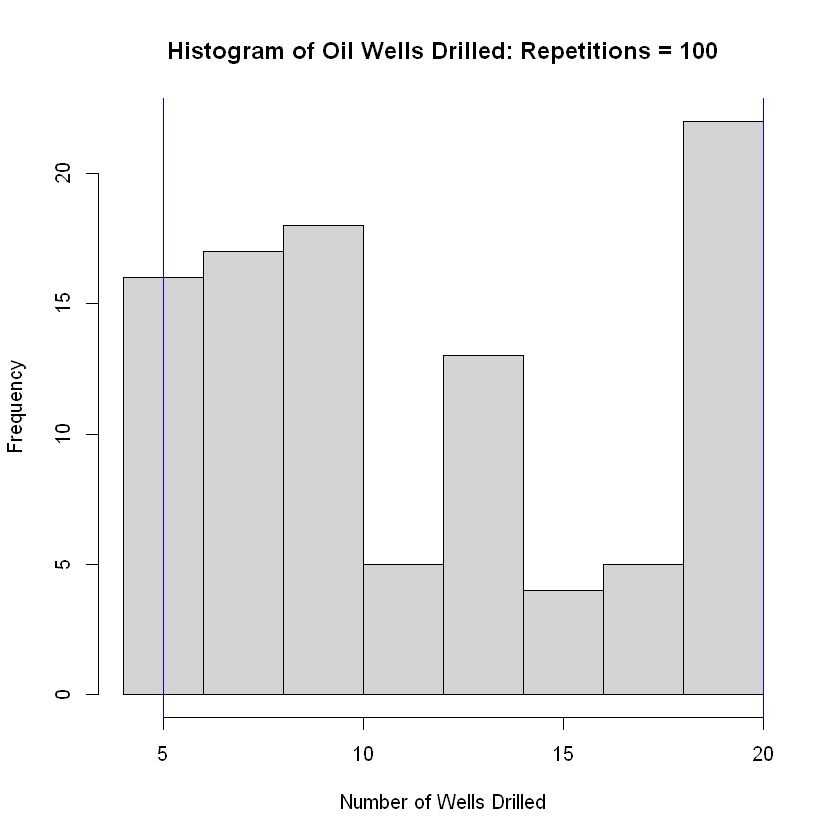

In [3]:
num_trials_needed <- c()     # create a vector to store the number of trials needed in while loop
num_samps = 100              # set the number of times to run the simulation

for (i in 1:num_samps){
    k <- 0     # Initialize number of successes index
    n <- 0     # Initialize number of total trials needed for success to occur
    while (k < 3 && n < 20) {
        k <- k + rflip(1, prob = 1/4, summarize = TRUE)[1,2]
        n <- n + 1
    }
    num_trials_needed[i] <- n     # store the number of trials need in this simulation
}

lower <- quantile(num_trials_needed, prob = 0.05)     # Calcuate the 5th percentile.
upper <- quantile(num_trials_needed, prob = 0.95)     # Calcuate the 95th percentile.
cat('The grand mean of the number of trials needed to achieve success is equal to\n   ',mean(num_trials_needed) )
hist(num_trials_needed, breaks = 8, main = 'Histogram of Oil Wells Drilled: Repetitions = 100', xlab = 'Number of Wells Drilled')
abline( v = lower, col="blue")     # Add vertical line at 5th percentile
abline(v = upper, col="blue")      # Add vertical line at 95th percentile 

This table summarizes the investigation to include five examples from the sampling distribution of Drawing a Spades hand:

<table class="center" style="width:70%; text-align:center;">
  <tr>
    <th>Max Number of Wells Drilled</th>
    <th>p = 1/4</th> 
    <th>E(X)</th>
    <th>Simulation Grand Mean</th>
  </tr>
  <tr>
    <td>100</td>
    <td>0.25</td>
    <td>12</td>
    <td>11.77</td>
  </tr>
  <tr>
    <td>200</td>
    <td>0.25</td>
    <td>12</td>
    <td>xx</td>
  </tr>
  <tr>
    <td>500</td>
    <td>0.25</td>
    <td>12</td>
    <td>xx</td>
  </tr>
  <tr>
    <td>1,000</td>
    <td>0.25</td>
    <td>12</td>
    <td>xx</td>
  </tr>
  <tr>

## Task

Complete the chart above by copy-pasting the while loop below using number of repetitions of 200, 500 and 1,000 and recording the results in the chart above.